# Multi-Class Diabetes Classification and Clustering

**Objective:** Build predictive models to classify diabetes status and explore patient segmentation using clustering technique.

**Author:** Manash Kumar Nepal

## 1. Data Loading

In [ ]:
# Initial imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
import math

In [ ]:
# Define dataset path
file_path = "Dataset of Diabetes .csv"

# Check if file exists
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
else:
    print("Dataset file not found. Please ensure it is in the same directory as this notebook.")

df.head()

Dataset loaded successfully.


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [ ]:
# Initial data analysis
print("Shape:", df.shape)
print("\nColumn Info:")
print(df.info())

print("\nClass Distribution:")
print(df["CLASS"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1000, 14)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB
None

Class Distribution:
CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64

Missing Values:
ID           0
No_Pation    0
Gen

## 2. Data Cleaning and Preparation

In [ ]:
# Remove whitespace inconsistencies
df["CLASS"] = df["CLASS"].str.strip()

print(df["CLASS"].value_counts())

CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


In [ ]:
# Drop identifier columns
df = df.drop(columns=["ID", "No_Pation"])

print(f"Updated Shape: {df.shape}")

Updated Shape: (1000, 12)


## 3. Exploratory Data Analysis

### 3.1 Target Variable Distribution

In [ ]:
# Class distribution percentage
df["CLASS"].value_counts(normalize=True) * 100

,proportion
CLASS,
Y,84.4
N,10.3
P,5.3


The dataset shows class imbalance, therefore evaluation metrics such as F1-score will be more important than accuracy.

In [ ]:
# Split the data into training and testing
X = df.drop(columns=["CLASS"])
y = df["CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Train class distributions:")
print(y_train.value_counts(normalize = True) * 100)
print("-"*35)
print("Test class distributions:")
print(y_test.value_counts(normalize = True) * 100)

Train class distributions:
CLASS
Y    84.375
N    10.250
P     5.375
Name: proportion, dtype: float64
-----------------------------------
Test class distributions:
CLASS
Y    84.5
N    10.5
P     5.0
Name: proportion, dtype: float64


### 3.2 Feature Distribution Analysis

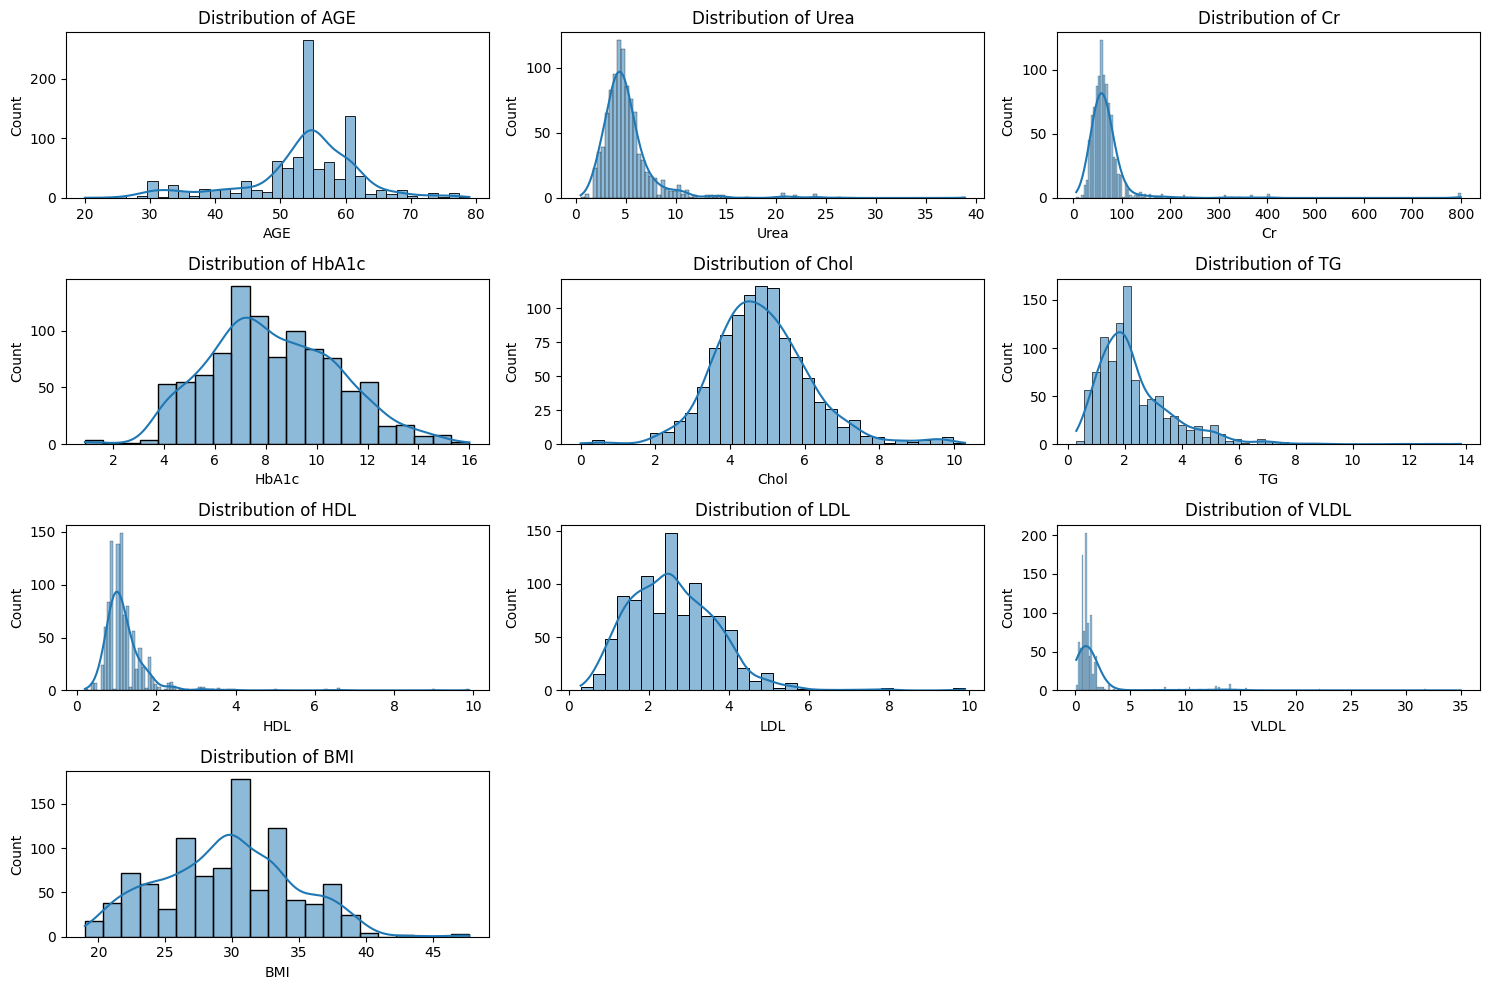

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
  plt.subplot(4,3,i+1)
  sns.histplot(df[col], kde=True)
  plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Most features show some level of skewness, especially measures like Urea, Cr, TG, and VLDL, which also contain a few extreme values. Variables such as Age, HbA1c, Chol, LDL and BMI appear more normally distributed.

### 3.3 Outlier Detection

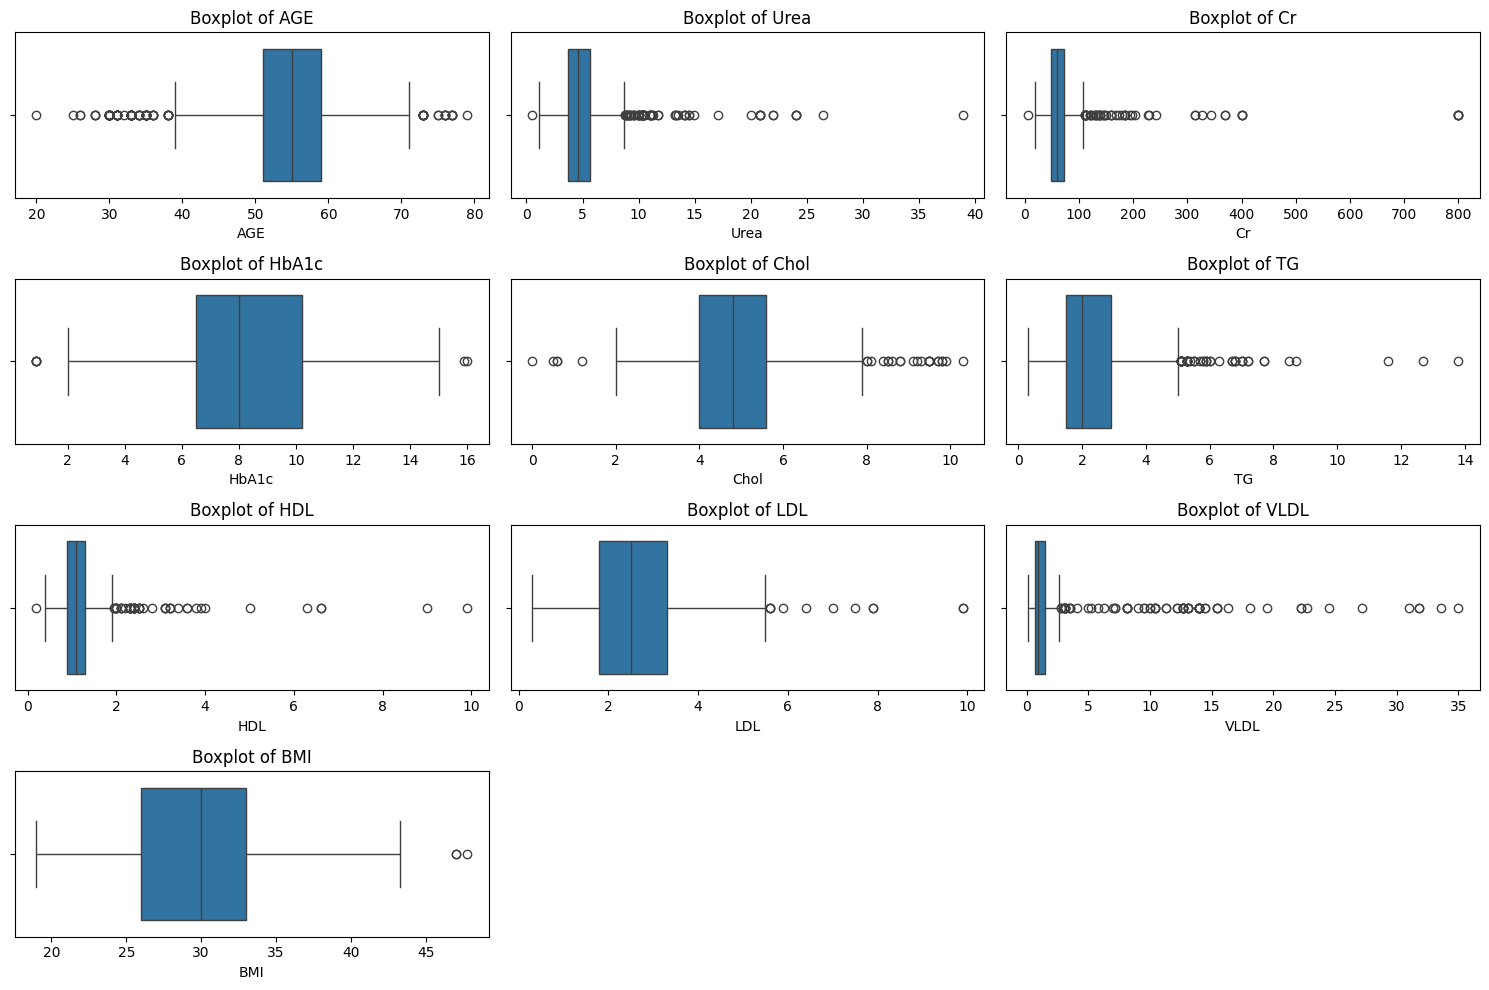

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
  plt.subplot(4,3,i+1)
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

The boxplots show the presence of outliers in multiple features, particularly in Urea, Cr, TG, HDL and VLDL.

### 3.4 Correlation Analysis

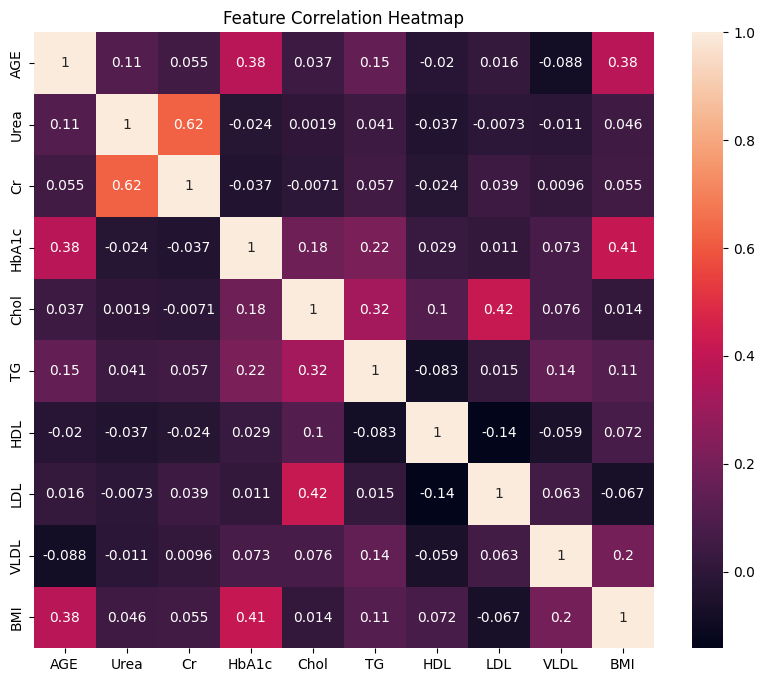

In [ ]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap shows mostly weak to moderate relationships between features. Some variables such as Urea-Cr and Chol-LDL exhibit higher correlation. Overall, multicollinearity does not appear to be severe.

## 4. Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Seperate the numerical and categorical features
numeric_features = ["AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL", "BMI"]
categorical_features = ["Gender"]

preprocessor = ColumnTransformer(
    transformers = [
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model evaluation function
def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  labels = model.classes_

  accuracy = accuracy_score(y_test, y_pred)
  print(f"Accuracy: {accuracy}")

  print(f"Classification report:\n{classification_report(y_test, y_pred)}")

  cm = confusion_matrix(y_test, y_pred, labels=labels)

  plt.figure(figsize=(6,5))
  sns.heatmap(cm, annot=True, xticklabels=labels, yticklabels=labels, cmap="Blues", fmt="d")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")

## 5. Model Development

### 5.1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_reg_pipeline = Pipeline(
    steps = [
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
    ]
)

logistic_reg_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['AGE', 'Urea', 'Cr', 'HbA1c',
                                                   'Chol', 'TG', 'HDL', 'LDL',
                                                   'VLDL', 'BMI']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

Accuracy: 0.935
Classification report:
              precision    recall  f1-score   support

           N       0.86      0.90      0.88        21
           P       0.47      0.70      0.56        10
           Y       0.99      0.95      0.97       169

    accuracy                           0.94       200
   macro avg       0.77      0.85      0.80       200
weighted avg       0.95      0.94      0.94       200



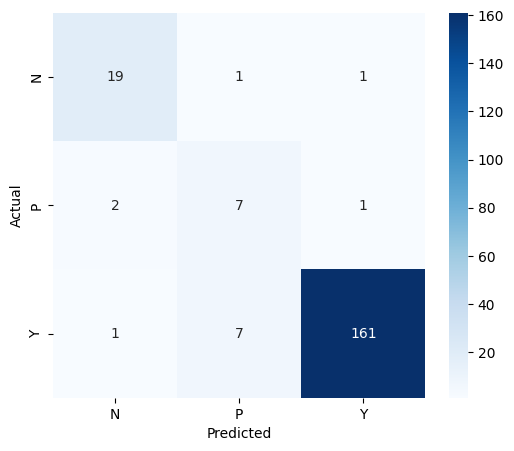

In [ ]:
# Evaluate Logistic Regression
evaluate_model(logistic_reg_pipeline, X_test, y_test)

Logistic Regression serves as a baseline model for comparison.

### 5.2 Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps = [
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['AGE', 'Urea', 'Cr', 'HbA1c',
                                                   'Chol', 'TG', 'HDL', 'LDL',
                                                   'VLDL', 'BMI']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

Accuracy: 0.995
Classification report:
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.90      0.95        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



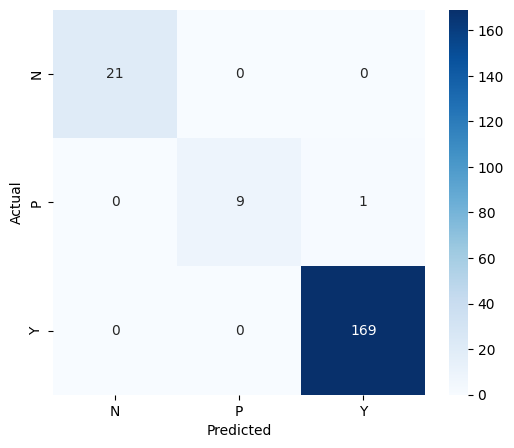

In [ ]:
# Evaluate Random Forest Classifier
evaluate_model(rf_pipeline, X_test, y_test)

Random Forest captures nonlinear relationships and improves predictive performance.

## 6. Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV
lr_cv_scores = cross_val_score(logistic_reg_pipeline, X, y, cv=skf, scoring="f1_weighted")
print(f"Logistic Regression CV scores: {lr_cv_scores}")
print(f"Average Logistic Regression CV score: {lr_cv_scores.mean()}")
print("-"*40)
# Random Forest CV
rf_cv_scores = cross_val_score(rf_pipeline, X, y, cv=skf, scoring="f1_weighted")
print(f"Random Forest CV scores: {rf_cv_scores}")
print(f"Average Random Forest CV score: {rf_cv_scores.mean()}")

Logistic Regression CV scores: [0.95724898 0.91428515 0.91178462 0.90714657 0.90271605]
Average Logistic Regression CV score: 0.918636274227576
----------------------------------------
Random Forest CV scores: [0.99494644 0.98992656 0.97061247 0.95674037 0.97514583]
Average Random Forest CV score: 0.977474336251578


In [ ]:
cv_results = pd.DataFrame({
    "Model" : ["Logistic Regression", "Random Forest"],
    "Average CV F1-score" : [lr_cv_scores.mean(), rf_cv_scores.mean()],
})
cv_results

,Model,Average CV F1-score
0,Logistic Regression,0.918636
1,Random Forest,0.977474


Cross-validation using Stratified K-Fold was performed to evaluate model performance more reliably. The results show that Random Forest achieves higher and more consistent F1-scores compared to Logistic Regression.

## 7. Hyperparameter Tuning

Best Logistic Parameters: {'model__C': 10}
Best Logistic CV scores: 0.9037499999999999
Accuracy: 0.94
Classification report:
              precision    recall  f1-score   support

           N       0.86      0.90      0.88        21
           P       0.50      0.80      0.62        10
           Y       0.99      0.95      0.97       169

    accuracy                           0.94       200
   macro avg       0.79      0.89      0.82       200
weighted avg       0.96      0.94      0.95       200



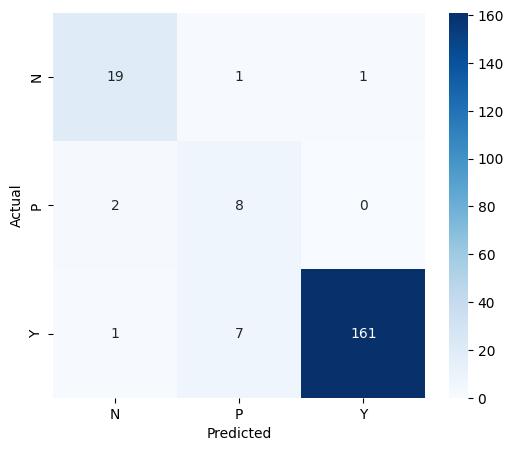

In [ ]:
# Logistic Regression
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    logistic_reg_pipeline,
    lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
lr_grid.fit(X_train, y_train)
print(f"Best Logistic Parameters: {lr_grid.best_params_}")
print(f"Best Logistic CV scores: {lr_grid.best_score_}")

# Evaluate tuned logistic regression model
best_lr_model = lr_grid.best_estimator_
evaluate_model(best_lr_model, X_test, y_test)

Best RF Params: {'model__max_depth': None, 'model__n_estimators': 100}
Best RF CV Score: 0.9737500000000001
Accuracy: 0.995
Classification report:
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.90      0.95        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



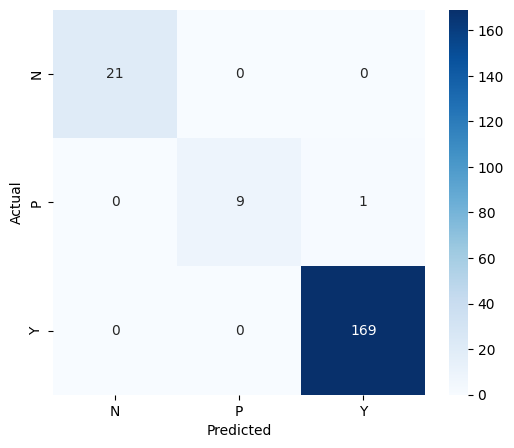

In [ ]:
# Random Forest
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV Score:", rf_grid.best_score_)

# Evaluate tuned logistic regression model
best_rf_model = rf_grid.best_estimator_
evaluate_model(best_rf_model, X_test, y_test)

Hyperparameter tuning was performed using GridSearchCV to find optimal model hyperparameters. Logistic Regression showed moderate improvement after tuning, while Random Forest achieved the best performance with high accuracy and strong classification results.

## 8. Feature Importance Analysis
Feature importance helps identify which medical indicators contribute most to diabetes prediction.

In [ ]:
# Extract feature importance
rf_model = rf_pipeline.named_steps["model"]
feature_names = rf_pipeline.named_steps["preprocessing"].get_feature_names_out()
feature_importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "features": feature_names,
    "feature importance": feature_importances
}).sort_values(by="feature importance", ascending=False)

feature_importance_df

,features,feature importance
3,numeric__HbA1c,4.176045e-01
9,numeric__BMI,1.930582e-01
0,numeric__AGE,1.437862e-01
4,numeric__Chol,4.904785e-02
5,numeric__TG,4.202921e-02
8,numeric__VLDL,4.052551e-02
7,numeric__LDL,3.005931e-02
1,numeric__Urea,2.837578e-02
2,numeric__Cr,2.444720e-02
6,numeric__HDL,1.628545e-02


HbA1c appears as the most influential feature, which aligns with medical understanding of diabetes diagnosis.

## 9. Patient Segmentation Using Clustering

In [ ]:
# Prepare the dataset for clustering

# Drop target variable
X_clustering = df.drop(columns=["CLASS"])

# Scale the data
X_scaled = preprocessor.fit_transform(X_clustering)

print(f"X_scaled Data:\n{X_scaled[:5]}")
print("-"*30)
print(f"Scaled shape: {X_scaled.shape}")

X_scaled Data:
[[-0.40114429 -0.14478078 -0.38267195 -1.3349833  -0.50943577 -1.03508433
   1.81075636 -1.08545731 -0.369958   -1.12462205  1.          0.
   0.        ]
 [-3.13001704 -0.21295413 -0.11580401 -1.3349833  -0.89372998 -0.67806268
  -0.1586921  -0.4573978  -0.34264878 -1.32623876  0.          1.
   0.        ]
 [-0.40114429 -0.14478078 -0.38267195 -1.3349833  -0.50943577 -1.03508433
   1.81075636 -1.08545731 -0.369958   -1.12462205  1.          0.
   0.        ]
 [-0.40114429 -0.14478078 -0.38267195 -1.3349833  -0.50943577 -1.03508433
   1.81075636 -1.08545731 -0.369958   -1.12462205  1.          0.
   0.        ]
 [-2.33409582  0.67329948 -0.38267195 -1.3349833   0.02857612 -0.96368
  -0.6131802  -0.54712059 -0.39726722 -1.72947219  0.          1.
   0.        ]]
------------------------------
Scaled shape: (1000, 13)


### 9.1 Optimal Cluster Selection

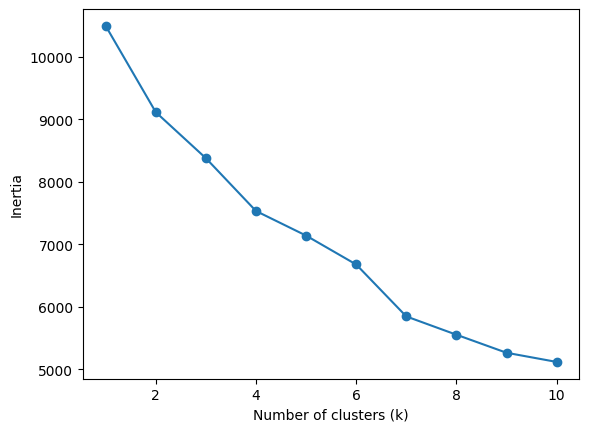

In [ ]:
# Find the optimal number of clusters

from sklearn.cluster import KMeans

inertia = []
k_range = range(1,11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

# Plotting the elbow curve
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

The inertia decreases rapidly from k = 1 to around k = 3-4, after which the rate of decrease becomes slower.

In [ ]:
# Silhouette score to get quantitative measure
from sklearn.metrics import silhouette_score

for k in range(2, 7):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  print(f"k = {k}, silhouette score = {score:.4f}")

k = 2, silhouette score = 0.1691
k = 3, silhouette score = 0.1480
k = 4, silhouette score = 0.1480
k = 5, silhouette score = 0.1440
k = 6, silhouette score = 0.1514


Although the dataset contains three labeled classes, the silhouette scores indicate that the data naturally forms two main clusters. This suggests that predict-diabetic patients may not form a clearly separate group and instead lie between normal and diabetic categories. Therefore, evaluating both k = 2 and k = 3 is reasonable for further analysis.

In [ ]:
# Clustering function

def kmeans_clustering(X_scaled, df, k):
  kmeans = KMeans(n_clusters=k, random_state=42)
  clusters = kmeans.fit_predict(X_scaled)

  df_cluster = df.copy()
  df_cluster[f"Cluster_{k}"] = clusters

  print(f"\nCluster Distribution for k={k}:")
  print(df_cluster[f"Cluster_{k}"].value_counts())

  print("-"*50)

  print(f"\nCluster vs True CLASS for k={k}:")
  print(pd.crosstab(df_cluster[f"Cluster_{k}"], df_cluster["CLASS"]))

  return df_cluster

### 9.2 Clustering with k = 2

In [ ]:
df_2 = kmeans_clustering(X_scaled, df, 2)


Cluster Distribution for k=2:
Cluster_2
1    759
0    241
Name: count, dtype: int64
--------------------------------------------------

Cluster vs True CLASS for k=2:
CLASS        N   P    Y
Cluster_2              
0          101  52   88
1            2   1  756


When k = 2, one cluster mainly consists of diabetic patients, while the second cluster contains mostly normal individuals along with some predict-diabetic and diabetic cases.

This means the algorithm separates patients into:

- A clear diabetic group
- A mixed group of normal and intermediate patients

So, the data naturally forms one severe diabetes cluster and one general population cluster.

### 9.3 Clustering with k = 3

In [ ]:
df_3 = kmeans_clustering(X_scaled, df, 3)


Cluster Distribution for k=3:
Cluster_3
0    505
1    259
2    236
Name: count, dtype: int64
--------------------------------------------------

Cluster vs True CLASS for k=3:
CLASS        N   P    Y
Cluster_3              
0            2   5  498
1            0   0  259
2          101  48   87


When k = 3, two clusters mostly contain diabetic patients, and one cluster contains a mix of all classes.

This shows that the model is dividing diabetic patients into two groups instead of forming three clear categories. So, k = 3 does not give clean or useful clusters.

## 10. Cluster Visualization Using PCA
PCA is used to reduce dimensionality and visualize clusters in 2D space.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

Explained Variance Ratio: [0.19067187 0.15622475]


The first two principal components capture a significant portion of the variance, making them suitable for visualization.

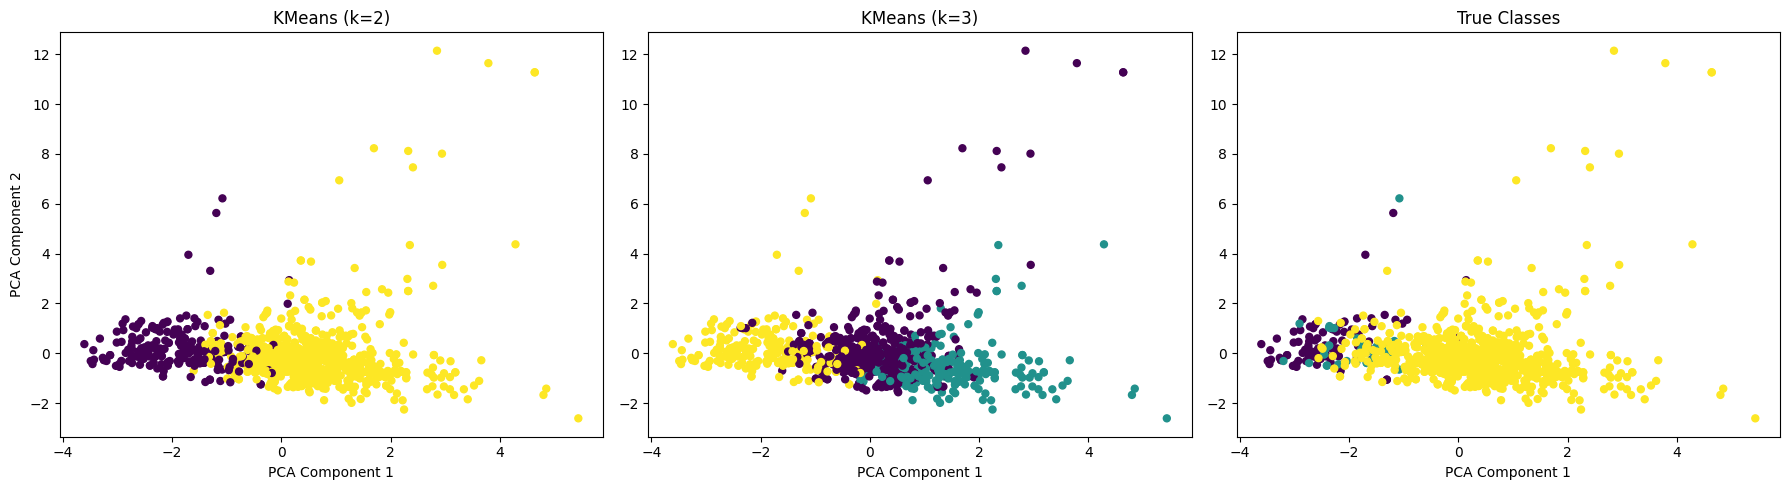

In [ ]:
# map true labels to numeric for coloring
label_map = {"N": 0, "P": 1, "Y": 2}
true_labels = df["CLASS"].map(label_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# k = 2
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df_2["Cluster_2"], cmap="viridis", s=25)
axes[0].set_title("KMeans (k=2)")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

# k = 3
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df_3["Cluster_3"], cmap="viridis", s=25)
axes[1].set_title("KMeans (k=3)")
axes[1].set_xlabel("PCA Component 1")

# true labels
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels, cmap="viridis", s=25)
axes[2].set_title("True Classes")
axes[2].set_xlabel("PCA Component 1")

plt.tight_layout()
plt.show()

## 11. Saving Trained Pipelines

In [ ]:
import joblib

joblib.dump(logistic_reg_pipeline, "logistic_regression_model.pkl")
print("Logistic Regression model saved successfully.")

joblib.dump(rf_pipeline, "random_forest_model.pkl")
print("Random Forest model saved successfully.")

Logistic Regression model saved successfully.
Random Forest model saved successfully.
